# Patch power spectrum → cosmological parameters (TT only)

Companion to `patch_cosmology_fit.ipynb`, restricted to the temperature
(TT) power spectrum only -- no polarization (TE, EE).

Purpose: with tau, Sigma-m_nu, and r fixed (see `cosmo_patch.fitting.camb_cl`),
the temperature power spectrum's dependence on the remaining 5 LambdaCDM
parameters (H0, Omega_b h^2, Omega_c h^2, As, ns) is fully captured by TT
alone -- TE and EE add extra *precision* (breaking some parameter
degeneracies and shrinking error bars) but don't inject any information
those parameters' equations don't already encode through TT. So this
notebook is expected to recover essentially the same best-fit parameters
as the joint TT+TE+EE notebook, just with larger uncertainties -- a
useful sanity check that adding TE/EE isn't *changing* what's being
measured, only sharpening it.

(tau itself is the one parameter TT alone genuinely can't pin down --
it's why it's fixed rather than fit in both notebooks; see the note in
Section 3.)

Requires: `healpy`, `pymaster`, `camb`, `iminuit`, `matplotlib`, and the
`cosmo_patch` module in this repo (`pip install -e .` from the project root).

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp

from cosmo_patch import patch, power_spectrum, fitting

## 1. Load the data: Planck SMICA half-mission maps + common mask (temperature only)

Same `hm1` x `hm2` cross-spectrum trick as the joint notebook -- their
instrumental noise is independent, so the cross-spectrum is free of noise
bias without a separate debiasing step -- but only the `I_STOKES` field
is needed here.

In [3]:
import os

INPUT_DIR = "input"
NSIDE = 2048
LMAX = 2011  # matches LMAX_TT in the joint notebook, for a direct comparison

FIDUCIAL = dict(H0=67.36, ombh2=0.02237, omch2=0.1200, As=2.1e-9, ns=0.9649)

hm1_path = os.path.join(INPUT_DIR, "COM_CMB_IQU-smica_2048_R3.00_hm1.fits")
hm2_path = os.path.join(INPUT_DIR, "COM_CMB_IQU-smica_2048_R3.00_hm2.fits")
mask_path = os.path.join(INPUT_DIR, "COM_Mask_CMB-common-Mask-Int_2048_R3.00.fits")

# field=0 -> I_STOKES; healpy converts NESTED (as stored) to RING automatically.
map_hm1_t = hp.read_map(hm1_path, field=0) * 1e6  # K_CMB -> uK_CMB
map_hm2_t = hp.read_map(hm2_path, field=0) * 1e6
common_mask = hp.read_map(mask_path, field=0)

cl_fiducial = fitting.camb_cl(**FIDUCIAL, lmax=LMAX)

f_sky = 0.7479


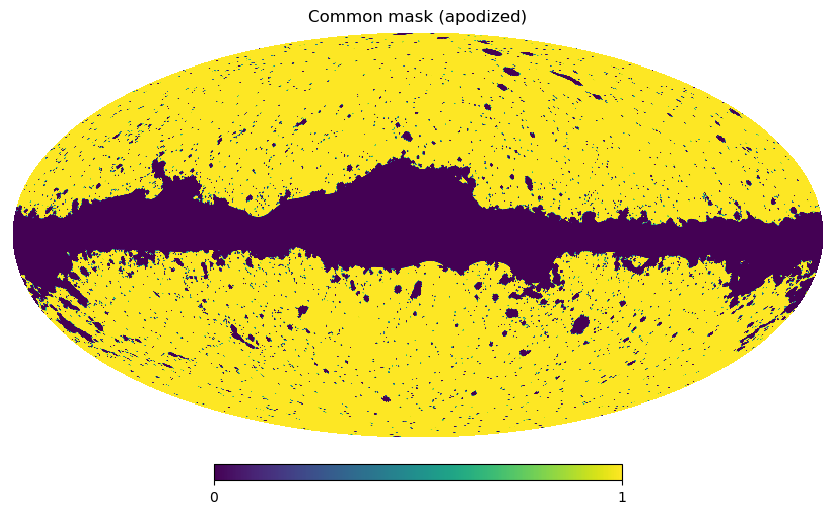

In [4]:
apodized_mask = patch.apodize_mask(common_mask, apodize_deg=0.3, method="C1")

p_t_hm1 = patch.extract_patch(map_hm1_t, apodized_mask)
p_t_hm2 = patch.extract_patch(map_hm2_t, apodized_mask)
print(f"f_sky = {p_t_hm1['f_sky']:.4f}")

hp.mollview(apodized_mask, title="Common mask (apodized)")

## 2. TT power spectrum + covariance (NaMaster)

Cross-spectrum of the two half-mission temperature fields, decoupled
through a single spin0 x spin0 mode-coupling workspace. Beam (5' Gaussian,
SMICA common resolution) and HEALPix pixel-window correction are folded
in. First bandpower (ell=[2,31]) dropped, same as the joint notebook.

In [4]:
beam_fwhm_arcmin = 5.0  # SMICA common resolution
beam_function = hp.gauss_beam(np.radians(beam_fwhm_arcmin / 60), lmax=LMAX)
pixel_window_t = hp.pixwin(NSIDE, lmax=LMAX)

field_t_hm1 = power_spectrum.build_field(
    p_t_hm1, spin=0, beam_function=beam_function, pixel_window_function=pixel_window_t, lmax=LMAX
)
field_t_hm2 = power_spectrum.build_field(
    p_t_hm2, spin=0, beam_function=beam_function, pixel_window_function=pixel_window_t, lmax=LMAX
)

bins = power_spectrum.make_bins(NSIDE, bandpower_width=30, lmax=LMAX)

spec_tt = power_spectrum.compute_power_spectrum(field_t_hm1, bins, field_b=field_t_hm2)
workspace_tt = spec_tt["workspace"]

n_tt = len(spec_tt["ell"]) - 1  # drop bin 0 (ell=[2,31])
ell_tt = spec_tt["ell"][1:1 + n_tt]
cl_data = spec_tt["cl"][1:1 + n_tt]

# hm1 and hm2 have independent noise -- their cross-spectrum above is
# noise-bias-free, but the *covariance* still needs each split's noise
# level, estimated from the half-difference null map (hm1 - hm2)/2, which
# cancels the shared CMB signal and leaves pure noise.
noise_tt = power_spectrum.estimate_noise_cl(
    map_hm1_t, map_hm2_t, apodized_mask, LMAX,
    beam_function=beam_function, pixel_window_function=pixel_window_t,
)

covariance = power_spectrum.compute_gaussian_covariance(
    workspace_tt, field_t_hm1, cl_fiducial["TT"], field_b=field_t_hm2,
    noise_cl_a=noise_tt, noise_cl_b=noise_tt,
)[1:1 + n_tt, 1:1 + n_tt]
errors = power_spectrum.compute_errors(covariance)
cov_inv = np.linalg.inv(covariance)

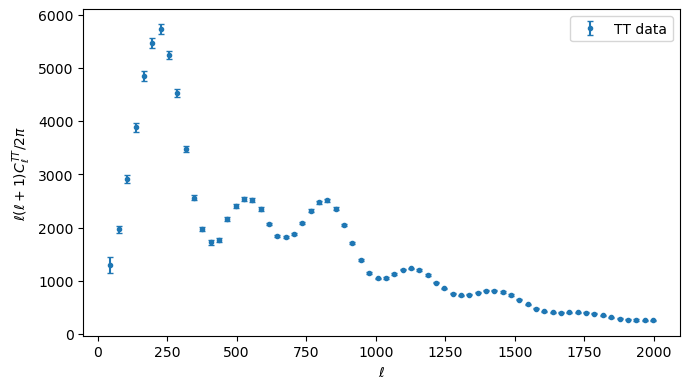

In [5]:
def to_dl(ell, cl):
    return ell * (ell + 1) / (2 * np.pi) * cl

dl_data = to_dl(ell_tt, cl_data)
dl_errors = to_dl(ell_tt, errors)

plt.figure(figsize=(7, 4))
plt.errorbar(ell_tt, dl_data, yerr=dl_errors, fmt="o", ms=3, capsize=2, label="TT data")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\ell(\ell+1)C_\ell^{TT}/2\pi$")
plt.legend()
plt.tight_layout()

## 3. Fit cosmological parameters (TT only)

Uses `fitting.FitDataTT`/`chi_square_tt`/`fit_parameters_tt` -- a
separate, self-contained TT-only path (not the joint TT+TE+EE functions
with TE/EE left empty). No spin0 x spin2 / spin2 x spin2 workspace, no
TE/EE terms in the chi^2, and no `A_ps_EE` parameter at all -- there's no
EE term here for a point-source amplitude to act on.

tau, Sigma-m_nu, and r stay fixed at the same defaults as the joint
notebook (see `fitting.camb_cl`) -- not because TT can't tolerate a free
tau mechanically, but because tau only enters TT through the combination
`As * exp(-2*tau)`, degenerate with As itself; without independent
large-scale E-mode information there's no way to break that degeneracy
from TT alone. This is the "except tau" caveat: every *other* parameter
has its own distinct imprint on the acoustic peaks (peak positions ->
H0/curvature-like effects, peak height ratios -> Omega_b h^2/Omega_c h^2,
tilt -> ns, overall amplitude -> As once the tau degeneracy is fixed by
hand) and so is expected to converge close to the fiducial values -- tau
is the one parameter that's fundamentally unconstrained by this spectrum
alone, which is exactly why the pipeline fixes it rather than fits it.

Sanity check first: chi^2 at the fiducial parameters should be close to
`n_tt` (66), not wildly off.

In [ ]:
fit_data = fitting.FitDataTT(
    cl_data=cl_data,
    cov_inv=cov_inv,
    workspace_tt=workspace_tt,
    lmax=LMAX,
    n_tt=n_tt,
)

chi2_at_truth = fitting.chi_square_tt(fit_data, **FIDUCIAL, A_ps_TT=50.0)
print(f"chi^2 at fiducial params = {chi2_at_truth:.1f}  (n_bins = {n_tt})")

In [ ]:
initial_guess = dict(
    H0=70.0, ombh2=0.022, omch2=0.11, As=2.0e-9, ns=0.96, A_ps_TT=50.0,
)
bounds = dict(
    H0=(50, 90),
    ombh2=(0.01, 0.03),
    omch2=(0.05, 0.30),
    As=(1e-9, 4e-9),
    ns=(0.9, 1.05),
    A_ps_TT=(0, 200),
)
# Rough expected uncertainty per parameter -- without this, MIGRAD's first
# numerical-gradient estimate can land in a negative-curvature region
# (wildly different parameter scales, e.g. H0~70 vs As~1e-9, condition it
# poorly) and trigger an expensive recovery search. See fit_parameters_tt's
# docstring. compute_minos stays off (the default) -- it's a separate,
# expensive profile-likelihood scan per free parameter that neither
# notebook actually reads (only the HESSE-based `errors` below).
initial_step = dict(
    H0=1.0, ombh2=5e-4, omch2=5e-3, As=5e-11, ns=0.01, A_ps_TT=10.0,
)
fixed_params_fullsky = set()  # this fit doesn't fix any parameters

result = fitting.fit_parameters_tt(
    fit_data, initial_guess, bounds, initial_step=initial_step, fixed=fixed_params_fullsky
)

print("Converged:", result["valid"])
print("chi^2 at best fit:", result["chi2"])
for name, val in result["best_fit"].items():
    err = result["errors"][name]
    truth = FIDUCIAL.get(name)
    truth_str = f"  (Planck 2018 fiducial: {truth})" if truth is not None else ""
    print(f"  {name} = {val:.5g} +/- {err:.3g}{truth_str}")

# Save the full-sky best-fit parameters + errors. "fullsky" vs "patched"
# (Section 4) in the filename keeps the two scopes apart in output/ -- the
# fixed/all_varied tag just checks whether fixed_params_fullsky is empty.
FULLSKY_OUTPUT_DIR = "output"
os.makedirs(FULLSKY_OUTPUT_DIR, exist_ok=True)
_fixed_tag_fullsky = f"fixed({','.join(sorted(fixed_params_fullsky))})" if fixed_params_fullsky else "all_varied"
FULLSKY_TAG = f"TT_{_fixed_tag_fullsky}"

fullsky_params_path = os.path.join(FULLSKY_OUTPUT_DIR, f"fullsky_params_{FULLSKY_TAG}.txt")
with open(fullsky_params_path, "w") as f:
    f.write(f"# Full-sky best-fit parameters (TT only, {_fixed_tag_fullsky})\n")
    f.write(f"converged={result['valid']}  chi2={result['chi2']:.2f}  n_bins={n_tt}\n")
    for name, val in result["best_fit"].items():
        err = result["errors"][name]
        truth = FIDUCIAL.get(name)
        truth_str = f"  (Planck 2018 fiducial: {truth})" if truth is not None else ""
        tag = " (fixed)" if name in fixed_params_fullsky else ""
        f.write(f"  {name} = {val:.6g} +/- {err:.4g}{truth_str}{tag}\n")
print(f"Saved {fullsky_params_path}")

## 4. Twelve Nside=1 patches: independent TT-only fits per patch

Same sky-directional consistency check as the joint notebook's Section 4, restricted to
TT (no TE/EE, no separate Pol mask): split the sky into the 12 disjoint superpixels of an
Nside=1 HEALPix grid (`patch.make_superpixel_mask`), intersect each with the common
intensity mask used above, re-apodize, and repeat the TT cross-spectrum + Gaussian
covariance + chi^2 pipeline independently on each patch, using the same
`fitting.FitDataTT`/`chi_square_tt`/`fit_parameters_tt` path as Section 3.

This section is self-contained: it only needs Section 1 (data loading) to have run, not
Section 2/3's expensive full-sky spectrum/covariance/fit -- `beam_fwhm_arcmin`, `to_dl`,
`initial_guess`, `bounds`, and `initial_step` are (re)defined locally below rather than
reused from Section 2/3, and the final comparison plot only draws the full-sky reference
line if Section 3's `result` happens to exist. Run Section 1, then jump straight here if
you don't want to pay for the full-sky fit.

Runs at full `NSIDE_PATCH=2048` and `LMAX_PATCH=2508` -- unlike the joint notebook's
Section 4, which downgrades to `nside=512` because it needs up to 6 covariance
workspaces per patch (TT/TE/EE cross-combinations across two different masks) and OOM-
killed its kernel at full resolution (see its Section 4 markdown). TT-only means a single
mask and a single spin0 x spin0 covariance workspace per patch -- the same cost as
Section 2's single full-sky covariance computation, just repeated per patch with
`gc.collect()` freeing each patch's workspace before the next is built -- so it stays
tractable at full resolution, and keeping the full `ell` range here (rather than
truncating to ell<=1000) is what keeps the per-patch error bars from blowing up: a
narrower multipole range throws away exactly the high-ell information that would
otherwise shrink them.

Patches the Galactic plane cut leaves with almost no usable sky (`f_sky` below
`MIN_FSKY`) are skipped rather than fit -- there's not enough signal left in them for a
meaningful constraint.

Text(0.5, 0.98, 'Nside=1 superpixel patches x intensity mask (apodized, Nside=2048)')

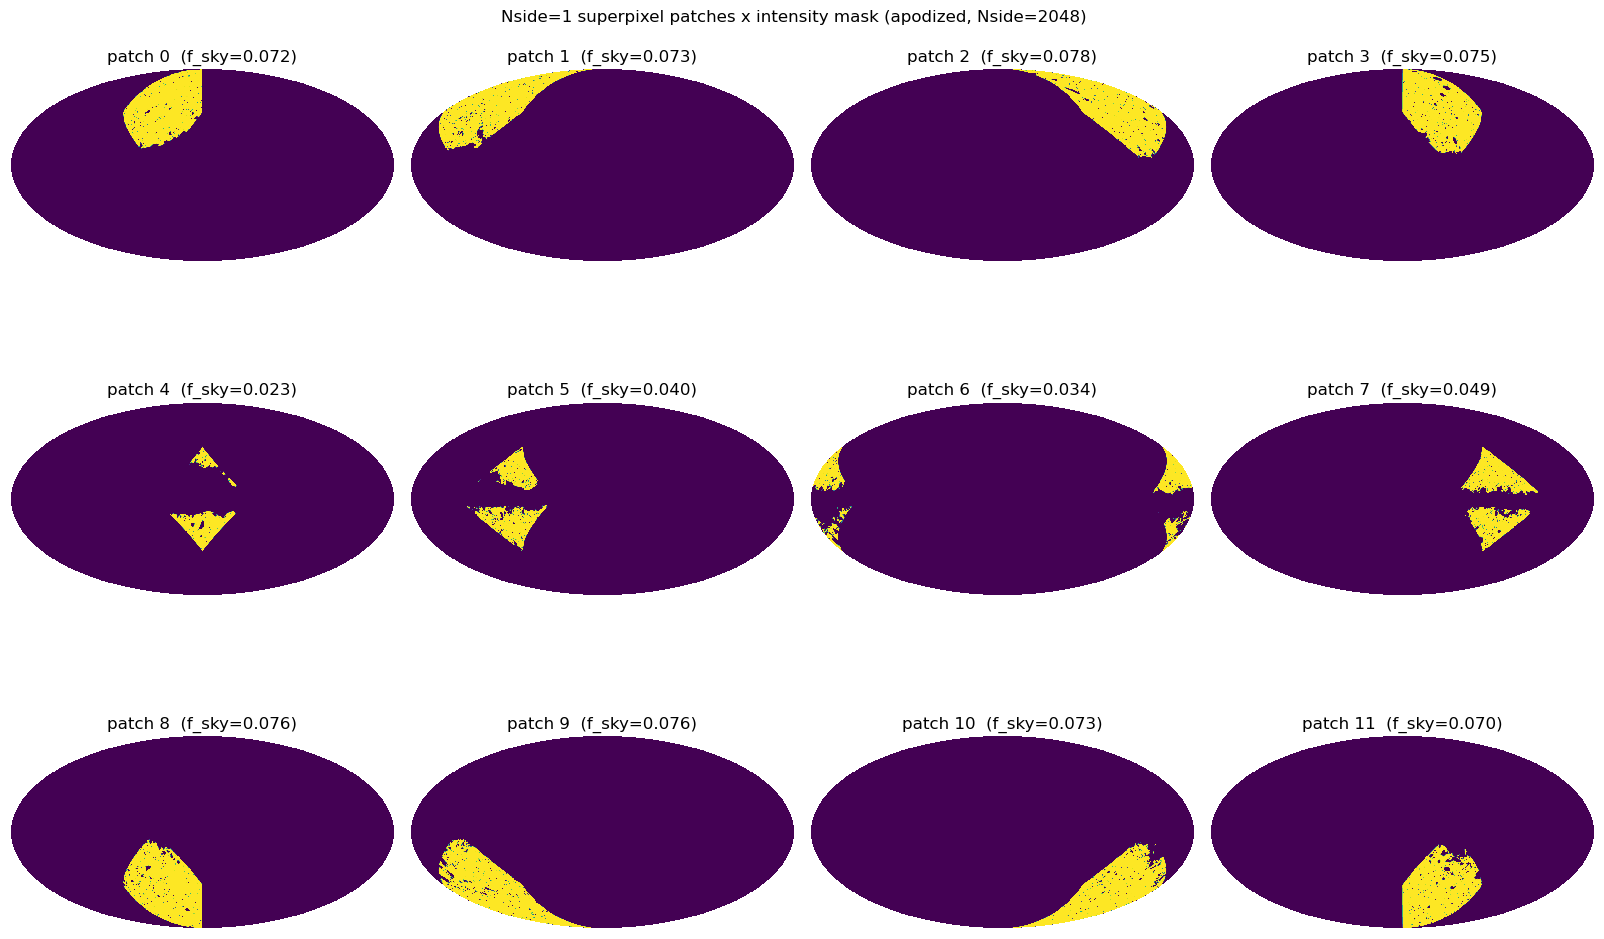

In [5]:
NSIDE_PATCH = 2048  # see markdown above -- TT-only patch fits stay tractable at full res
NSIDE_LOW = 1
N_PATCHES = hp.nside2npix(NSIDE_LOW)  # 12

map_hm1_t_lo = hp.ud_grade(map_hm1_t, NSIDE_PATCH)
map_hm2_t_lo = hp.ud_grade(map_hm2_t, NSIDE_PATCH)
common_mask_lo = hp.ud_grade(common_mask, NSIDE_PATCH)

patch_masks, patch_fsky = [], []
for i in range(N_PATCHES):
    super_mask = patch.make_superpixel_mask(NSIDE_PATCH, NSIDE_LOW, i)
    mask_i = patch.apodize_mask(super_mask * common_mask_lo, apodize_deg=0.3, method="C1")
    patch_masks.append(mask_i)
    patch_fsky.append(np.mean(mask_i ** 2))

plt.figure(figsize=(16, 10))
for i in range(N_PATCHES):
    hp.mollview(
        patch_masks[i], sub=(3, 4, i + 1), title=f"patch {i}  (f_sky={patch_fsky[i]:.3f})",
        cbar=False, notext=True, min=0, max=1,
    )
plt.suptitle(f"Nside=1 superpixel patches x intensity mask (apodized, Nside={NSIDE_PATCH})")

In [ ]:
import gc

# Self-contained config for this section -- doesn't rely on Sections 2/3
# having run, so Section 4 works right after Section 1 (data loading)
# alone, without paying for the expensive full-sky spectrum/covariance/fit.
def to_dl(ell, cl):
    return ell * (ell + 1) / (2 * np.pi) * cl

beam_fwhm_arcmin = 5.0  # SMICA common resolution
initial_guess = dict(
    H0=70.0, ombh2=0.022, omch2=0.11, As=2.0e-9, ns=0.96, A_ps_TT=50.0,
)
fixed_params = {"ns", "As"}  # H0, ombh2, omch2, A_ps_TT,
for _param in fixed_params:
    initial_guess[_param] = FIDUCIAL[_param]
bounds = dict(
    H0=(50, 90),
    ombh2=(0.01, 0.03),
    omch2=(0.05, 0.30),
    As=(1e-9, 4e-9),
    ns=(0.9, 1.05),
    A_ps_TT=(0, 200),
)
initial_step = dict(
    H0=1.0, ombh2=5e-4, omch2=5e-3, As=5e-11, ns=0.01, A_ps_TT=10.0,
)

LMAX_PATCH = 2508  # max multipole informative at this patch/beam/pixel scale
BANDPOWER_WIDTH_PATCH = 90
MIN_FSKY = 0.02  # skip patches the Galactic-plane cut leaves too small to fit

# Output naming -- tags plots/parameter dumps below with which params were
# held fixed (e.g. "fixed(As,ns)", or "all_varied" if none) and that this
# is the TT-only notebook, so files from both notebooks/settings don't
# collide in output/. "patched" (vs Section 3/5's "fullsky") keeps the two
# scopes apart too.
PATCHED_OUTPUT_DIR = "output"
os.makedirs(PATCHED_OUTPUT_DIR, exist_ok=True)
_fixed_tag = f"fixed({','.join(sorted(fixed_params))})" if fixed_params else "all_varied"
PATCHED_TAG = f"TT_{_fixed_tag}"

beam_function_patch = hp.gauss_beam(np.radians(beam_fwhm_arcmin / 60), lmax=LMAX_PATCH)
pixel_window_t_patch = hp.pixwin(NSIDE_PATCH, lmax=LMAX_PATCH)
cl_fiducial_patch = fitting.camb_cl(**FIDUCIAL, lmax=LMAX_PATCH)


def fit_one_patch_tt(i):
    """Run the TT-only cross-spectrum + Gaussian covariance + chi^2 fit on patch i alone."""
    mask_i = patch_masks[i]

    p_t_hm1_i = patch.extract_patch(map_hm1_t_lo, mask_i)
    p_t_hm2_i = patch.extract_patch(map_hm2_t_lo, mask_i)

    field_t_hm1_i = power_spectrum.build_field(
        p_t_hm1_i, spin=0, beam_function=beam_function_patch,
        pixel_window_function=pixel_window_t_patch, lmax=LMAX_PATCH,
    )
    field_t_hm2_i = power_spectrum.build_field(
        p_t_hm2_i, spin=0, beam_function=beam_function_patch,
        pixel_window_function=pixel_window_t_patch, lmax=LMAX_PATCH,
    )

    bins_i = power_spectrum.make_bins(NSIDE_PATCH, bandpower_width=BANDPOWER_WIDTH_PATCH, lmax=LMAX_PATCH)

    spec_tt_i = power_spectrum.compute_power_spectrum(field_t_hm1_i, bins_i, field_b=field_t_hm2_i)
    ws_tt_i = spec_tt_i["workspace"]

    n_tt_i = len(spec_tt_i["ell"]) - 1  # drop bin 0 (ell=[2,31])
    ell_i = spec_tt_i["ell"][1:1 + n_tt_i]
    cl_i = spec_tt_i["cl"][1:1 + n_tt_i]

    noise_tt_i = power_spectrum.estimate_noise_cl(
        map_hm1_t_lo, map_hm2_t_lo, mask_i, LMAX_PATCH,
        beam_function=beam_function_patch, pixel_window_function=pixel_window_t_patch,
    )

    cov_i = power_spectrum.compute_gaussian_covariance(
        ws_tt_i, field_t_hm1_i, cl_fiducial_patch["TT"], field_b=field_t_hm2_i,
        noise_cl_a=noise_tt_i, noise_cl_b=noise_tt_i,
    )[1:1 + n_tt_i, 1:1 + n_tt_i]
    errors_i = power_spectrum.compute_errors(cov_i)
    cov_inv_i = np.linalg.inv(cov_i)

    fit_data_i = fitting.FitDataTT(
        cl_data=cl_i, cov_inv=cov_inv_i, workspace_tt=ws_tt_i,
        lmax=LMAX_PATCH, n_tt=n_tt_i,
    )
    result_i = fitting.fit_parameters_tt(
        fit_data_i, initial_guess, bounds, initial_step=initial_step, fixed=fixed_params
    )

    return dict(f_sky=p_t_hm1_i["f_sky"], ell=ell_i, cl_data=cl_i, errors=errors_i, result=result_i)


patch_results = {}
for i in range(N_PATCHES):
    if patch_fsky[i] < MIN_FSKY:
        print(f"patch {i}: f_sky={patch_fsky[i]:.4f} -- too small, skipped")
        continue
    print(f"patch {i}: f_sky={patch_fsky[i]:.4f} -- fitting...")
    patch_results[i] = fit_one_patch_tt(i)
    r = patch_results[i]["result"]
    print(f"  converged={r['valid']}  chi2={r['chi2']:.1f}  "
          f"H0={r['best_fit']['H0']:.2f} +/- {r['errors']['H0']:.2f}")
    gc.collect()

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(14, 14))
for i, ax in zip(range(N_PATCHES), axes.flat):
    if i not in patch_results:
        ax.set_visible(False)
        continue
    r = patch_results[i]
    ell = r["ell"]
    dl = to_dl(ell, r["cl_data"])
    dl_err = to_dl(ell, r["errors"])
    ax.errorbar(ell, dl, yerr=dl_err, fmt="o", ms=3, capsize=2)
    ax.set_title(f"patch {i}  (f_sky={r['f_sky']:.3f})", fontsize=9)
    ax.set_xlabel(r"$\ell$")
fig.suptitle(r"Per-patch TT bandpowers: $\ell(\ell+1)C_\ell^{TT}/2\pi$")
plt.tight_layout()

bandpowers_path = os.path.join(PATCHED_OUTPUT_DIR, f"patched_bandpowers_{PATCHED_TAG}.png")
fig.savefig(bandpowers_path, dpi=150)
print(f"Saved {bandpowers_path}")

In [ ]:
param_names = ["H0", "ombh2", "omch2", "As", "ns"]
patch_ids = sorted(patch_results)

fig, axes = plt.subplots(len(param_names), 1, figsize=(8, 12), sharex=True)
for ax, name in zip(axes, param_names):
    vals = [patch_results[i]["result"]["best_fit"][name] for i in patch_ids]
    errs = [patch_results[i]["result"]["errors"][name] for i in patch_ids]
    ax.errorbar(patch_ids, vals, yerr=errs, fmt="o", capsize=3, label="per-patch")
    if "result" in globals():  # only if Section 3's full-sky fit was also run
        ax.axhline(result["best_fit"][name], color="k", ls="--", lw=1, label="full-sky TT-only fit")
    ax.axhline(FIDUCIAL[name], color="gray", ls=":", lw=1, label="Planck 2018 fiducial")
    ax.set_ylabel(name)
axes[0].legend(fontsize=8)
axes[-1].set_xlabel("Nside=1 patch index")
axes[-1].set_xticks(patch_ids)
fig.suptitle("Best-fit parameters recovered independently per patch (TT only)")
plt.tight_layout()

params_plot_path = os.path.join(PATCHED_OUTPUT_DIR, f"patched_params_{PATCHED_TAG}.png")
fig.savefig(params_plot_path, dpi=150)
print(f"Saved {params_plot_path}")

# Dump each patch's best-fit parameters + errors (TT only) to a text file
# alongside the plots, tagged the same way so the two stay paired.
params_txt_path = os.path.join(PATCHED_OUTPUT_DIR, f"patched_params_{PATCHED_TAG}.txt")
with open(params_txt_path, "w") as f:
    f.write(f"# Per-patch best-fit parameters (TT only, {_fixed_tag})\n")
    for i in patch_ids:
        r = patch_results[i]["result"]
        f.write(f"\npatch {i}: f_sky={patch_results[i]['f_sky']:.4f}  "
                f"converged={r['valid']}  chi2={r['chi2']:.2f}\n")
        for name, val in r["best_fit"].items():
            err = r["errors"][name]
            tag = " (fixed)" if name in fixed_params else ""
            f.write(f"  {name} = {val:.6g} +/- {err:.4g}{tag}\n")
print(f"Saved {params_txt_path}")

## 5. Validate: residuals and best-fit overlay

In [ ]:
best_cosmo = {k: v for k, v in result["best_fit"].items() if k in FIDUCIAL}
best_cl = fitting.camb_cl(**best_cosmo, lmax=LMAX)
ps_tt = fitting.point_source_dl_template(LMAX, result["best_fit"]["A_ps_TT"])

theory_tt = fitting.decouple_theory(workspace_tt, [best_cl["TT"] + ps_tt])[1:1 + n_tt]
ps_tt_binned = fitting.decouple_theory(workspace_tt, [ps_tt])[1:1 + n_tt]

dl_data = to_dl(ell_tt, cl_data)
dl_theory = to_dl(ell_tt, theory_tt)
dl_errors = to_dl(ell_tt, errors)

fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True,
                          gridspec_kw={"height_ratios": [3, 1]})

axes[0].errorbar(ell_tt, dl_data, yerr=dl_errors, fmt="o", ms=3, capsize=2, label="data")
axes[0].plot(ell_tt, dl_theory, "-", label="best-fit theory")
axes[0].plot(ell_tt, to_dl(ell_tt, ps_tt_binned), "k--", lw=1, label=r"$A_{ps}^{TT}$")
axes[0].set_ylabel(r"$\ell(\ell+1)C_\ell^{TT}/2\pi$")
axes[0].legend()

residual = (cl_data - theory_tt) / errors
axes[1].axhline(0, color="k", lw=0.8)
axes[1].plot(ell_tt, residual, "o", ms=3)
axes[1].set_ylabel(r"$(\mathrm{data-theory})/\sigma$")
axes[1].set_xlabel(r"$\ell$")
plt.tight_layout()

fullsky_spectrum_path = os.path.join(FULLSKY_OUTPUT_DIR, f"fullsky_spectrum_{FULLSKY_TAG}.png")
fig.savefig(fullsky_spectrum_path, dpi=150)
print(f"Saved {fullsky_spectrum_path}")

## 6. Parameter constraints

Same profile-likelihood contour as the joint notebook. Expect this
contour to be visibly *wider* than the TT+TE+EE version for the same
patch -- TT alone measures the same H0-Omega_c h^2 degeneracy direction,
just with less precision.

In [ ]:
m = result["minuit"]
plt.figure(figsize=(5, 5))
m.draw_mncontour("H0", "omch2", cl=[1, 2])
plt.title(r"$1\sigma$/$2\sigma$ contours: $H_0$ vs $\Omega_c h^2$ (TT only)")
plt.tight_layout()